# Perform ARIMA analysis on the data

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.ticker import MultipleLocator
from scipy.stats import boxcox

- Let us work with PD here for simplicity. 

In [14]:
data = pd.read_csv(r"../../Data/misc/sol_sind_all.txt", sep=r'\s+', skip_blank_lines=True, header=0)
data.columns = ["JD", "sind"]

time_obj = Time(data["JD"].to_numpy()  + 2400000, format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')
data


,JD,sind,year
datetime,,,
1966-09-02 08:34:04.799986,39370.857,0.173873,1966.669013
1966-09-03 08:13:55.199989,39371.843,0.175041,1966.671713
1966-09-04 07:55:12.000006,39372.830,0.174457,1966.674415
1966-09-24 08:16:48.000018,39392.845,0.175236,1966.729213
1966-09-25 07:56:38.399980,39393.831,0.175918,1966.731912
...,...,...,...
2016-02-06 02:06:43.199999,57424.588,0.165300,2016.097435
2016-02-10 02:44:09.600005,57428.614,0.164400,2016.108457
2016-02-13 02:45:36.000019,57431.615,0.168500,2016.116674


- *We can refit on train and valid before test set evaluation*

In [15]:
# Downsample before split

data_df_year = data.resample('YE').median().interpolate('time', limit =5) # resample years into groups, asfreq takes one per group 
data_df_6me = data.resample('6ME').median().interpolate('time', limit = 6)
data_df_me = data.resample('ME').median().interpolate('time', limit = 6)
data_df_gapme = data[data['year'] > 1973].resample('ME').median().interpolate('time', limit = 6) # use all data after 1973

In [16]:
def split_df(df, train_split=0.6, valid_split=0.39):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

train_df, valid_df, test_df = split_df(data)
train_df_year,  valid_df_year,  test_df_year  = split_df(data_df_year)
train_df_6me,   valid_df_6me,   test_df_6me   = split_df(data_df_6me)
train_df_me,    valid_df_me,    test_df_me    = split_df(data_df_me)
train_df_gapme, valid_df_gapme, test_df_gapme = split_df(data_df_gapme)

for name, (train, valid, test) in {
    "data" : (train_df, valid_df, test_df),
    "year"  : (train_df_year,  valid_df_year,  test_df_year),
    "6me"   : (train_df_6me,   valid_df_6me,   test_df_6me),
    "me"    : (train_df_me,    valid_df_me,    test_df_me),
    "gapme" : (train_df_gapme, valid_df_gapme, test_df_gapme),
}.items():
    print(f"{name:>6}- train: {train.shape}, valid: {valid.shape}, test: {test.shape}")

  data- train: (3809, 3), valid: (2477, 3), test: (63, 3)
  year- train: (31, 3), valid: (19, 3), test: (1, 3)
   6me- train: (60, 3), valid: (39, 3), test: (1, 3)
    me- train: (356, 3), valid: (232, 3), test: (6, 3)
 gapme- train: (302, 3), valid: (197, 3), test: (5, 3)


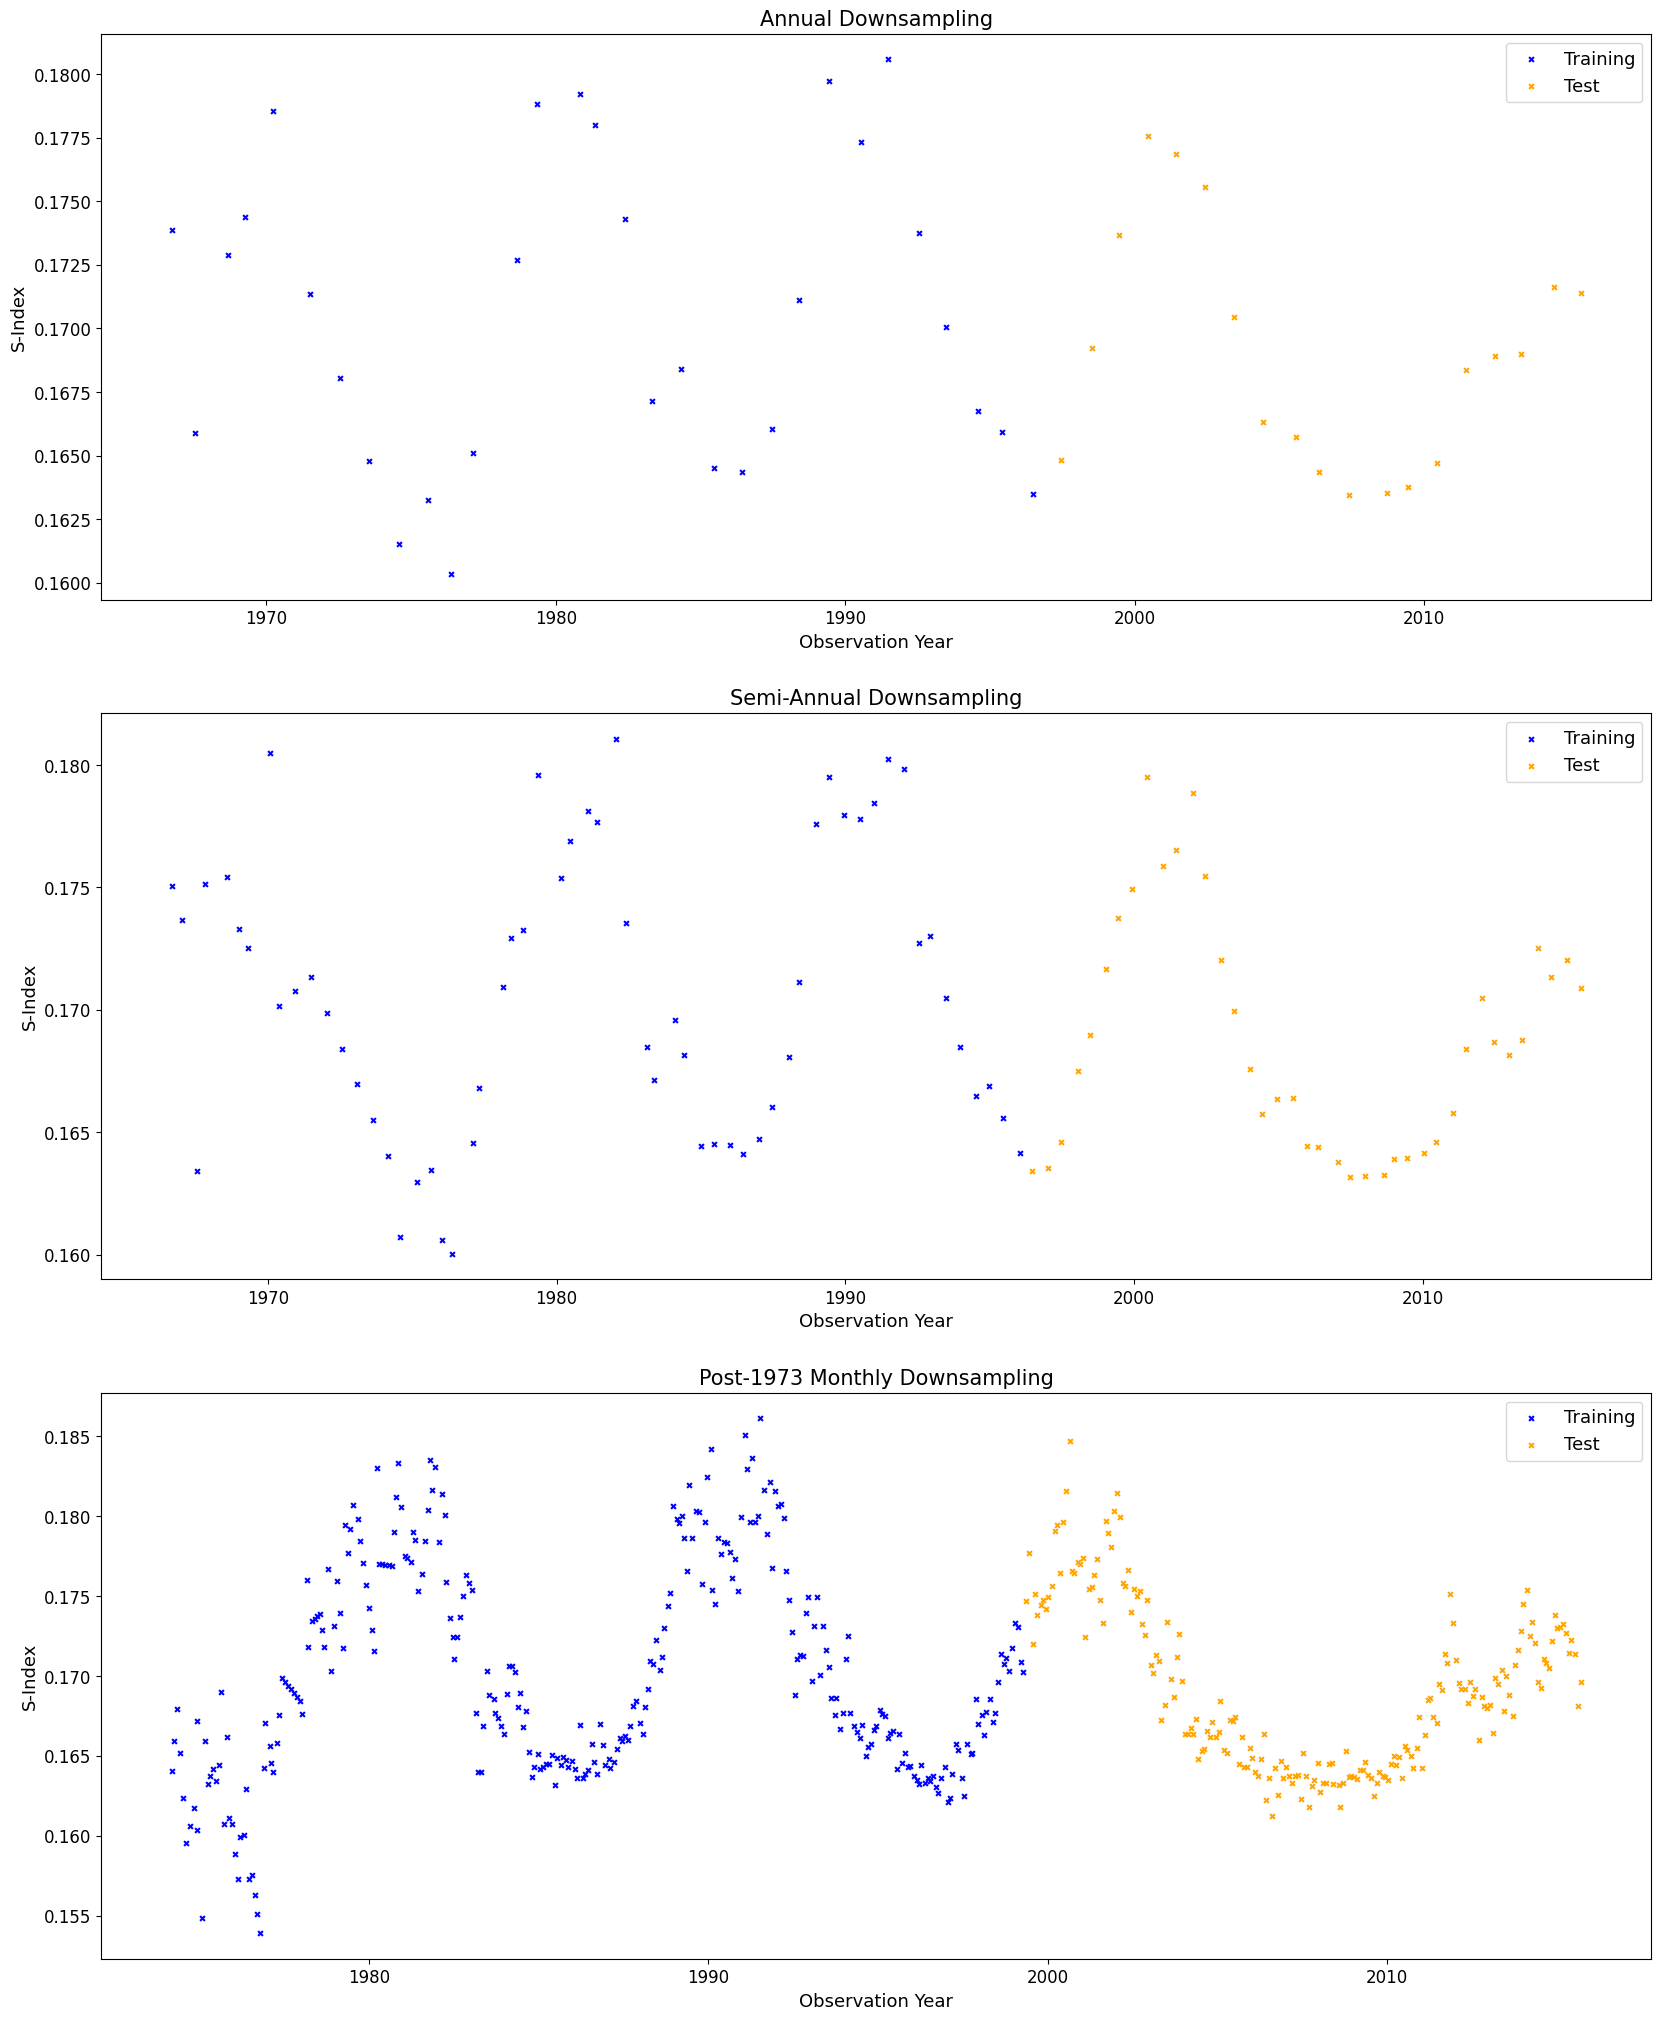

In [17]:
fig, ax = plt.subplots(3, figsize=(20, 25))

ax[0].scatter(train_df_year['year'], train_df_year['sind'], marker='x', s=12, alpha=1, color='blue', label='Training')
ax[0].scatter(valid_df_year['year'], valid_df_year['sind'], marker='x', s=12, alpha=1, color='orange', label='Test')
ax[0].set_ylabel("S-Index", fontsize=13)
ax[0].set_xlabel("Observation Year", fontsize=13)
ax[0].tick_params(axis='both', labelsize=12)
ax[0].set_title("Annual Downsampling", fontsize=15)
ax[0].legend(fontsize=13)

ax[1].scatter(train_df_6me['year'], train_df_6me['sind'], marker='x', s=12, alpha=1, color='blue', label='Training')
ax[1].scatter(valid_df_6me['year'], valid_df_6me['sind'], marker='x', s=12, alpha=1, color='orange', label='Test')
ax[1].set_ylabel("S-Index", fontsize=13)
ax[1].set_xlabel("Observation Year", fontsize=13)
ax[1].tick_params(axis='both', labelsize=12)
ax[1].set_title("Semi-Annual Downsampling", fontsize=15)
ax[1].legend(fontsize=13)

ax[2].scatter(train_df_gapme['year'], train_df_gapme['sind'], marker='x', s=12, alpha=1, color='blue', label='Training')
ax[2].scatter(valid_df_gapme['year'], valid_df_gapme['sind'], marker='x', s=12, alpha=1, color='orange', label='Test')
ax[2].set_ylabel("S-Index", fontsize=13)
ax[2].set_xlabel("Observation Year", fontsize=13)
ax[2].tick_params(axis='both', labelsize=12)
ax[2].set_title("Post-1973 Monthly Downsampling", fontsize=15)
ax[2].legend(fontsize=13)

# Save
fig.savefig(r"../../Report/Figures/SolarDownsamplings.png")
plt.show()

- Now we want to check for stationarity to make sure the ARIMA model is applicable.
- Let us examine the training dataset to prevent data leakage.

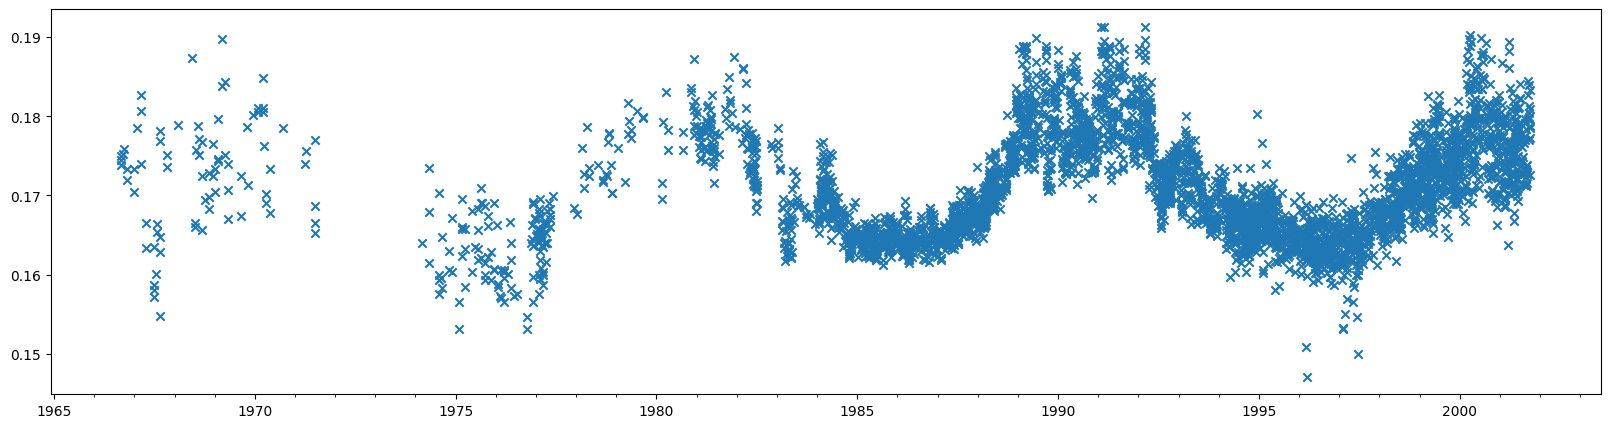

In [18]:
fig, ax = plt.subplots(figsize=(20,5))
plt.scatter(train_df["year"], train_df['sind'], marker='x')
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

- Looks vaguely sinusoidal
- Peaks at 1970ish and 1981ish
- Troughs at 1976ish and 1986ish
- This corresponds to the roughly 10 to 11 year solar cycle

----

- The variance of the data does not look constant
- We can check the mean of the data by checking the average values at the minima we have observed

In [19]:
trough1976 = data[data['year'].between(1975,1977)]
trough1986 = data[data['year'].between(1985,1987)]
mean1976 = trough1976['sind'].mean()
mean1986 = trough1986['sind'].mean()
mean_delta = abs(mean1976-mean1986)
data_range = data['sind'].max() - data['sind'].min()
print(f"The change in means is {mean_delta} out of overall range delta {data_range}")
print(f'Percentage {100*mean_delta/data_range:.2f}%')


The change in means is 0.0019412766020864003 out of overall range delta 0.044209
Percentage 4.39%


- This seems similar enough considering the uncertainty in the estimating the trough.
- Now how to fix the variance.
- No idea how the variance varies so use a Box-Cox transform to normalise.

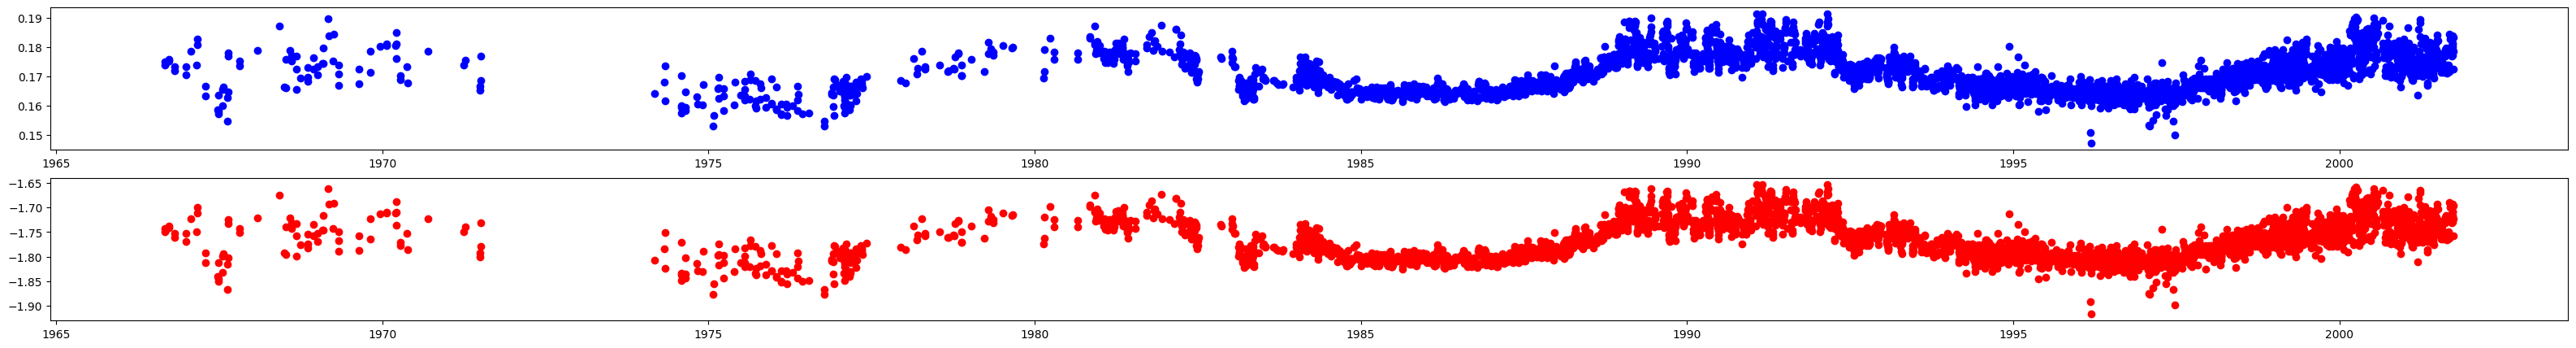

In [20]:
# train_df['sind_norm'], lambda_ = boxcox(train_df['sind']) 
train_df['sind_norm'] = np.log(train_df['sind'])
fig, ax = s=plt.subplots(2,1 ,figsize=(40,5))
ax[0].scatter(train_df['year'], train_df['sind'], color = 'blue')
ax[1].scatter(train_df['year'], train_df['sind_norm'], color = 'red')
# lambda_

In [21]:
# Apply the log transform to all 4

train_df_year['sind_norm'] = np.log(train_df_year['sind'])
train_df_6me['sind_norm'] = np.log(train_df_6me['sind'])
train_df_me['sind_norm'] = np.log(train_df_me['sind'])
train_df_gapme['sind_norm'] = np.log(train_df_gapme['sind'])


In [22]:
len(train_df_year)

31

- The next problem is that the data is not at fixed timesteps. 
- That four year gap is really problematic. Let's try interpolating it.
- This is still problematic. If we downsample to years we have very few datapoints but if we downsample to months we have too many interpolated ones. 
- Some approaches to try approaches:
    - Downsample to years; interpolate gap. 
    - Downsample to 6 months; reduced gap interpolation.
    - Downsample to months; massive interpolation.
    - Start analysis after gap; interp to month.
- The downsampling restricts the resolution of the solar cycle predictions.

In [23]:
na = [train_df_year.isna().sum(),
      train_df_6me.isna().sum(),
      train_df_me.isna().sum(),
      train_df_gapme.isna().sum(),
      ]

pd.set_option('display.max_rows', None)
print(na)
pd.reset_option('display.max_rows')

[JD           0
sind         0
year         0
sind_norm    0
dtype: int64, JD           0
sind         0
year         0
sind_norm    0
dtype: int64, JD           25
sind         25
year         25
sind_norm    25
dtype: int64, JD           0
sind         0
year         0
sind_norm    0
dtype: int64]


- The train_df_me has NaN values so let's skip that dataset.

In [24]:
from math import floor
# Print maxlags
def max_lags(df):
    n = len(df['sind_norm'])
    return floor(n/2)

print(f"{len(train_df_year)} datapoints in train_df_year, max lags = {max_lags(train_df_year)}")
print(f"{len(train_df_6me)} datapoints in train_df_6me, max lags = {max_lags(train_df_6me)}")
print(f"{len(train_df_gapme)} datapoints in train_df_gapme, max lags = {max_lags(train_df_gapme)}")


31 datapoints in train_df_year, max lags = 15
60 datapoints in train_df_6me, max lags = 30
302 datapoints in train_df_gapme, max lags = 151


- Now let's plot the ACF and PACF.
- Note to self: 
    - ACF is the correlation between a series and a lagged version of itself.
    - PACF is the correlation between a series and a lagged version with indirect effects removed.
    - The shaded bands indicate the regions in which the values would fall if they were white noise.

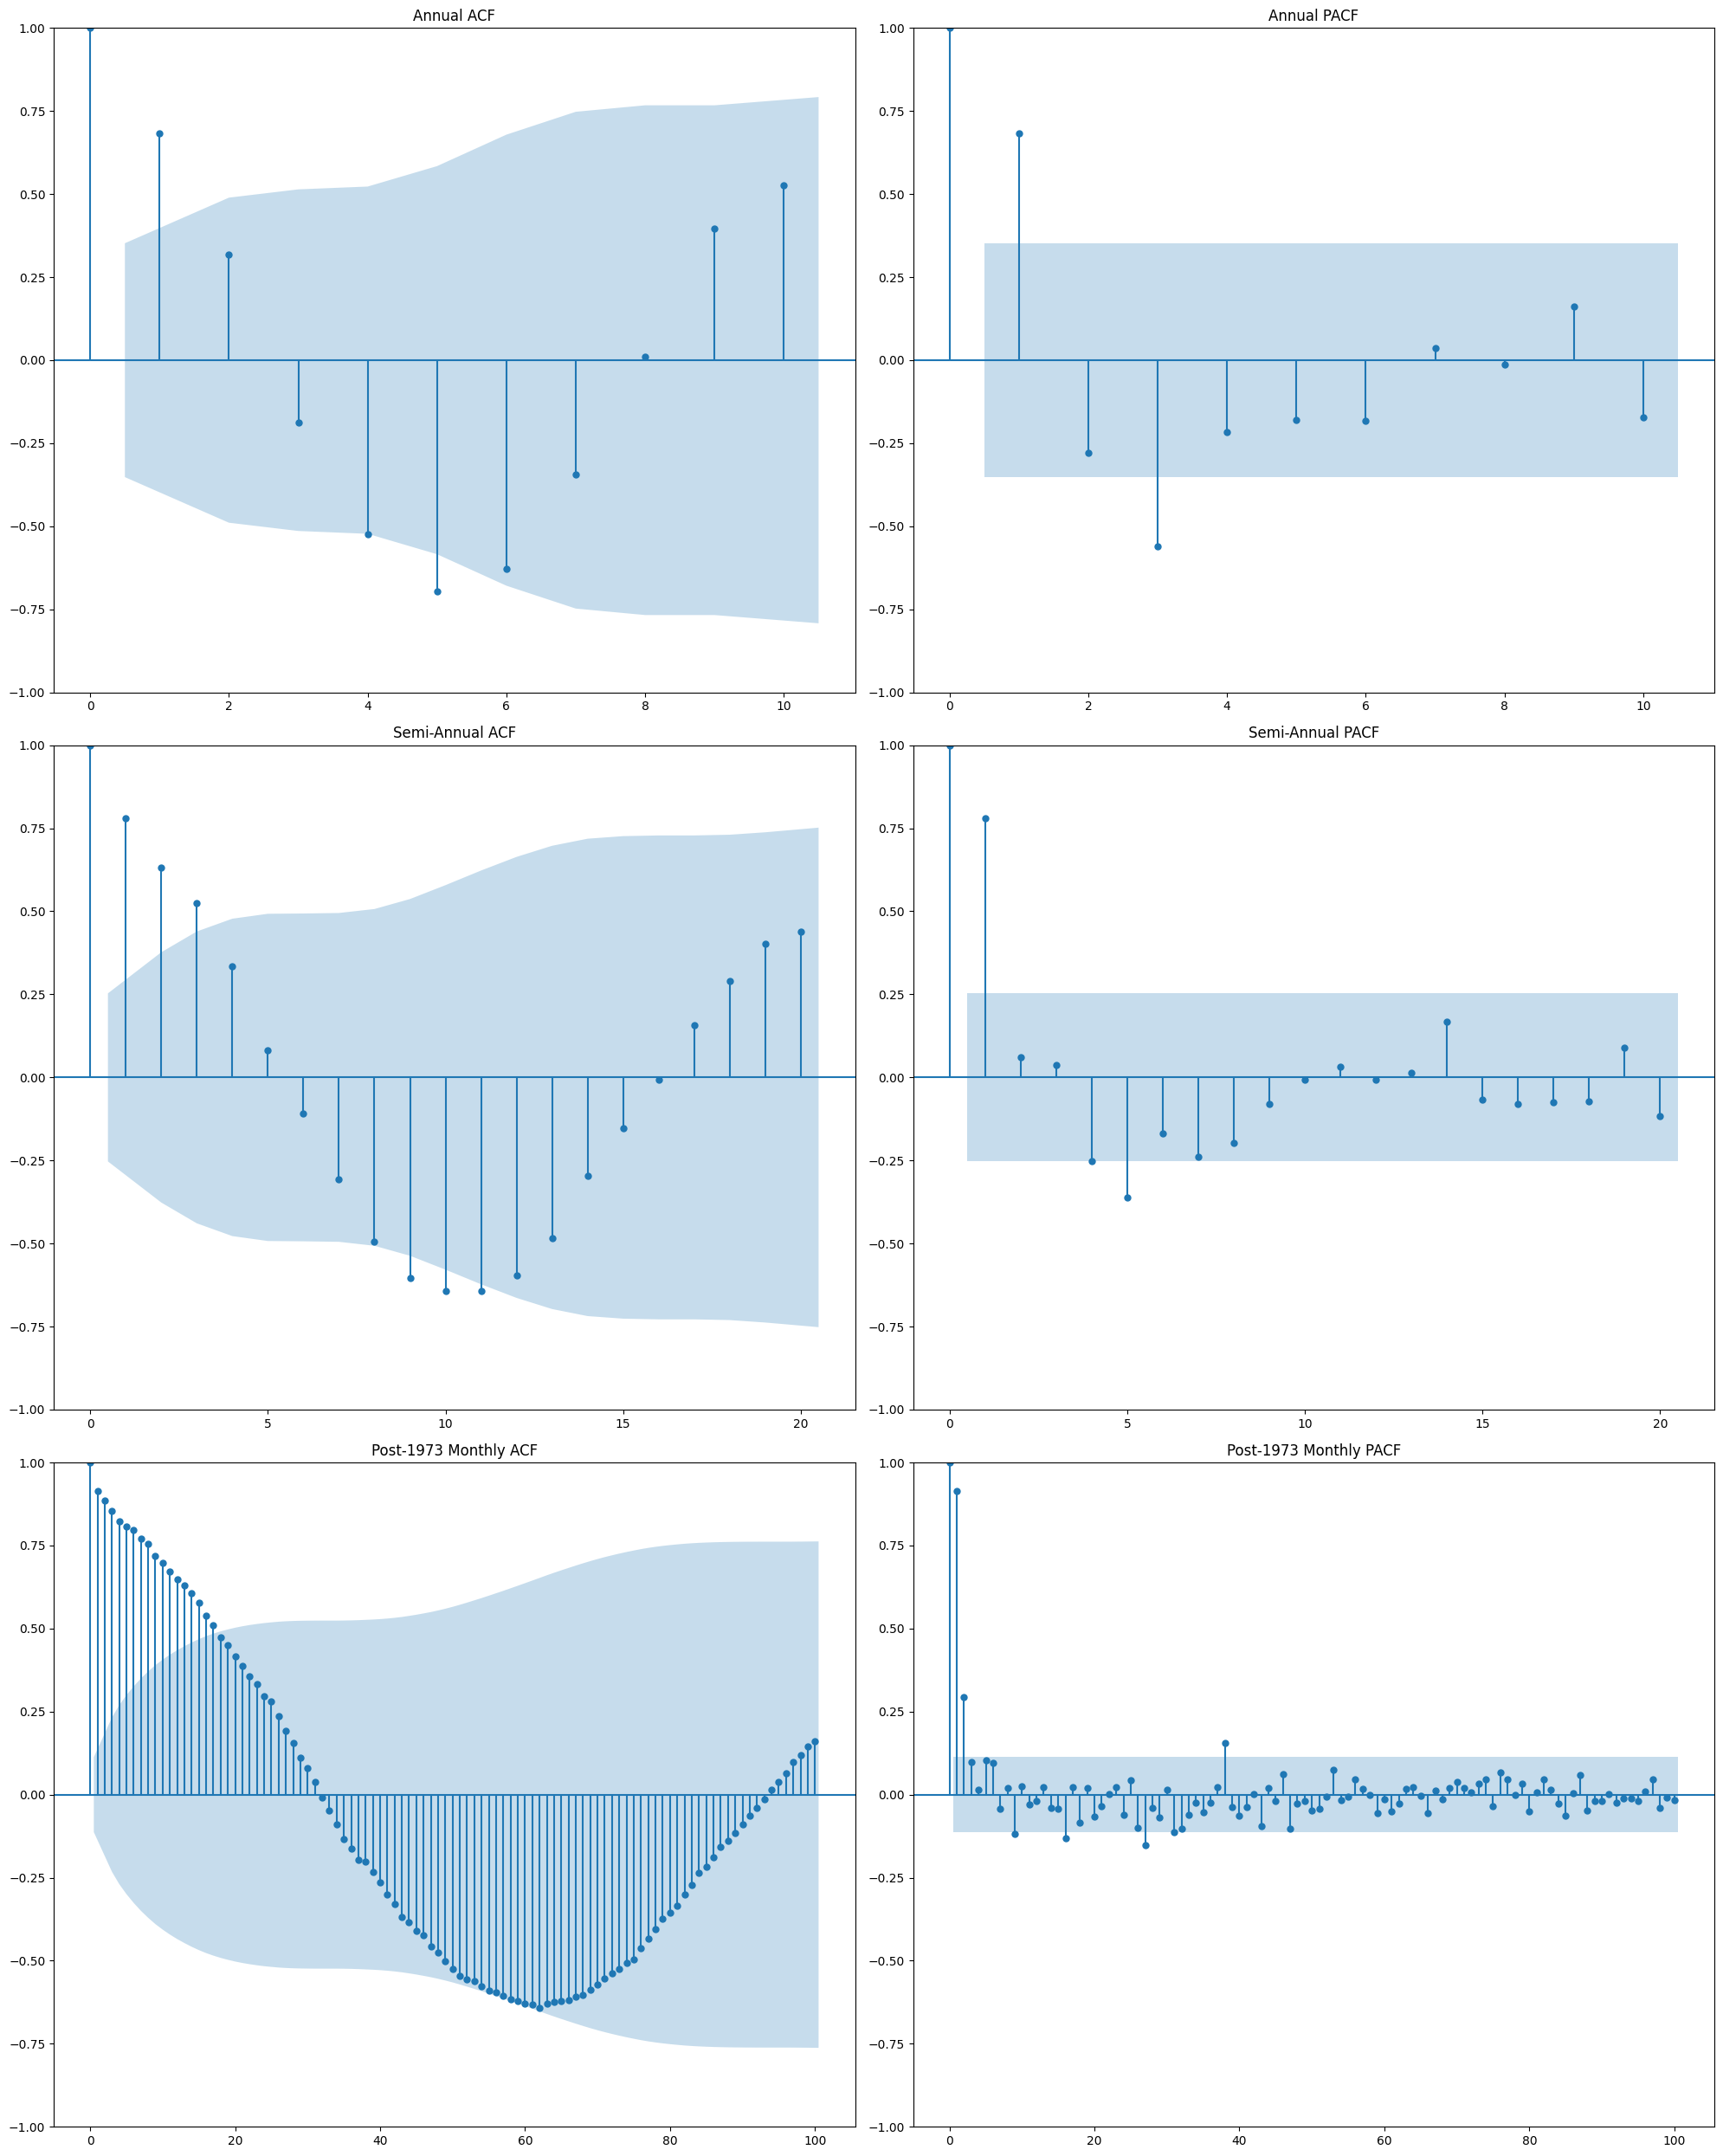

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(3, 2, figsize=(20, 25))

plot_acf(train_df_year['sind'],   lags=10, ax=ax[0,0])
plot_pacf(train_df_year['sind'],  lags=10, ax=ax[0,1])
ax[0,0].set_title('Annual ACF')
ax[0,1].set_title('Annual PACF')

plot_acf(train_df_6me['sind'],    lags=20, ax=ax[1,0])
plot_pacf(train_df_6me['sind'],   lags=20, ax=ax[1,1])
ax[1,0].set_title('Semi-Annual ACF')
ax[1,1].set_title('Semi-Annual PACF')

plot_acf(train_df_gapme['sind'],  lags=100, ax=ax[2,0])
plot_pacf(train_df_gapme['sind'], lags=100, ax=ax[2,1])
ax[2,0].set_title('Post-1973 Monthly ACF')
ax[2,1].set_title('Post-1973 Monthly PACF')

plt.tight_layout()

fig.savefig(r"../../Report/Figures/SolarACFPACF.png")

plt.show()

- The annual and semi-annual data downsamples show cyclic behaviour within 11 yeah cycles. 
    - The PACFs of these are dominated by the first two terms. This could be AR(2) (q=2)
- The monthly shows a negative correlation at 60 months =  5 years = aprox. half the solar cycle.

#### Check the seasonal ACF/PACF

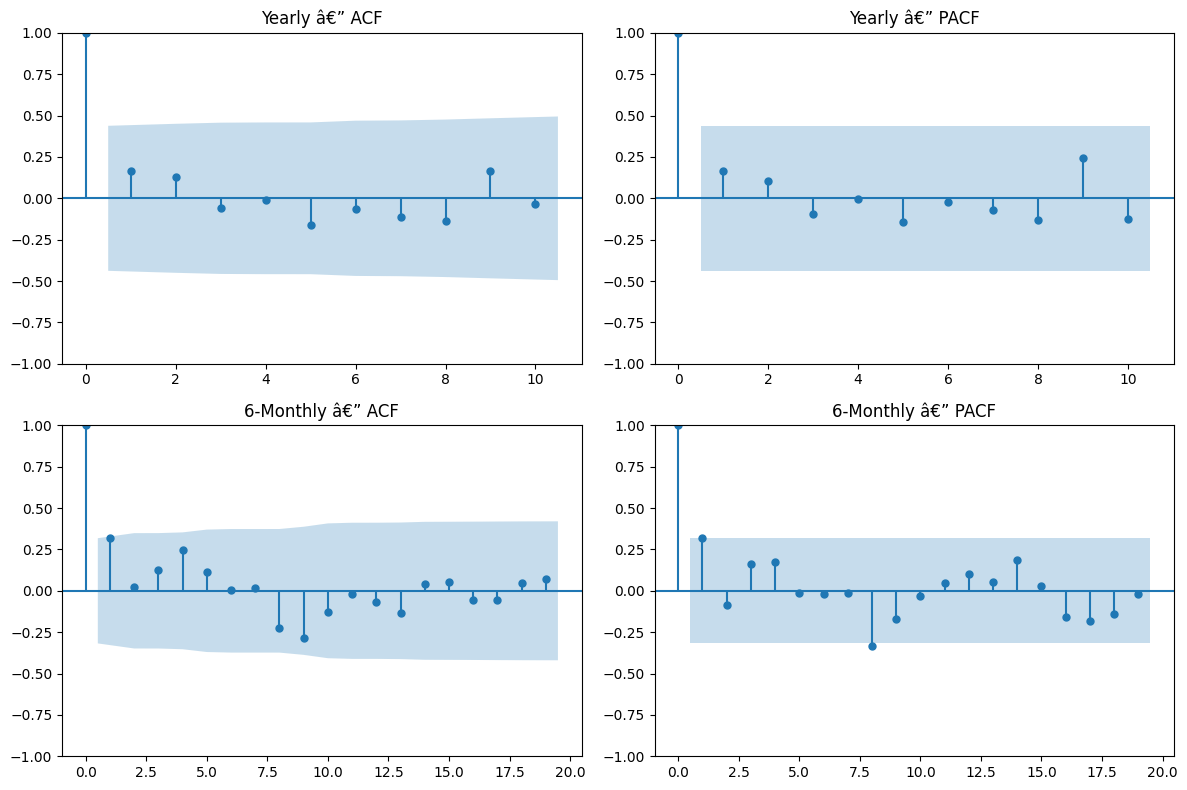

In [26]:
# Calculate the ACF/PACF for the seasonal data

# yearly
m = 11
seasonal_diff_year = train_df_year['sind_norm'].diff(m).dropna()

# semiannual
m = 22
seasonal_diff_6me = train_df_6me['sind_norm'].diff(m).dropna()

# Plot

def _max_lags(diff):
    n = len(diff)
    return floor(n/2)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(seasonal_diff_year,   lags=_max_lags(seasonal_diff_year), ax=ax[0,0])
plot_pacf(seasonal_diff_year,  lags=_max_lags(seasonal_diff_year), ax=ax[0,1])
ax[0,0].set_title('Yearly â€” ACF')
ax[0,1].set_title('Yearly â€” PACF')

plot_acf(seasonal_diff_6me,    lags=_max_lags(seasonal_diff_6me), ax=ax[1,0])
plot_pacf(seasonal_diff_6me,   lags=_max_lags(seasonal_diff_6me), ax=ax[1,1])
ax[1,0].set_title('6-Monthly â€” ACF')
ax[1,1].set_title('6-Monthly â€” PACF')

plt.tight_layout()
plt.show()

- It is hard to estimate the initial guesses for the P and Q for the seasonal model since it is mostly noise. 

#### Actually training the ARIMAs

- pmdarima implements the rather nifty Hyndman-Khandakar search algo for p and q.
- I have decided on no differencing.
- Used AICc to correct for small sample sizes.

In [31]:
import pmdarima as pm
model_year = pm.auto_arima(
    train_df_year['sind'],
    seasonal = True, 
    start_q = 2,
    start_p = 2,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    D=0,
    maxp = 10,
    maxq = 10,
    trace = True,
    m =11,
)

model_6me = pm.auto_arima(
    train_df_6me['sind'],
    seasonal = True, 
    start_q = 2,
    start_p = 4,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    maxp = 10,
    maxq = 10,
    trace = True,
    m = 22,
)
# model_gapme = pm.auto_arima(
#     train_df_gapme['sind_norm'],
#     # seasonal = True, # the cycle is longer than that
#     start_q = 2,
#     stepwise = True,
#     information_criterion='aicc',
#     d = 0,
#     maxp = 10,
#     maxq = 10,
#     trace = True,
#     # m =132
# )

Performing stepwise search to minimize aicc
 ARIMA(2,0,2)(1,0,1)[11] intercept   : AICC=-242.276, Time=1.86 sec
 ARIMA(0,0,0)(0,0,0)[11] intercept   : AICC=-225.758, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[11] intercept   : AICC=-246.010, Time=0.83 sec
 ARIMA(0,0,1)(0,0,1)[11] intercept   : AICC=inf, Time=0.42 sec
 ARIMA(0,0,0)(0,0,0)[11]             : AICC=-19.569, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[11] intercept   : AICC=-243.660, Time=0.05 sec
 ARIMA(1,0,0)(2,0,0)[11] intercept   : AICC=-242.845, Time=0.77 sec
 ARIMA(1,0,0)(1,0,1)[11] intercept   : AICC=-243.882, Time=0.85 sec
 ARIMA(1,0,0)(0,0,1)[11] intercept   : AICC=-246.580, Time=0.38 sec
 ARIMA(1,0,0)(0,0,2)[11] intercept   : AICC=-243.572, Time=0.57 sec
 ARIMA(1,0,0)(1,0,2)[11] intercept   : AICC=-240.373, Time=0.68 sec
 ARIMA(0,0,0)(0,0,1)[11] intercept   : AICC=inf, Time=0.30 sec
 ARIMA(2,0,0)(0,0,1)[11] intercept   : AICC=-241.946, Time=0.14 sec
 ARIMA(1,0,1)(0,0,1)[11] intercept   : AICC=-241.867, Time=0.43 sec
 ARIMA(2,0,1)(0

In [32]:
print("Year downsampling:")
# print(model_year.summary())
print(f'Best order: {model_year.order}  seasonal: {model_year.seasonal_order}')
print(f'AICc: {model_year.aicc():.3f}')

print("Semi-annual downsampling:")
# print(model_6me.summary())
print(f'Best order: {model_6me.order}  seasonal: {model_6me.seasonal_order}')
print(f'AICc: {model_6me.aicc():.3f}')

# print("Post 73' monthly downsampling:")
# # print(model_gapme.summary())
# print(f'Best order: {model_gapme.order}  seasonal: {model_gapme.seasonal_order}')
# print(f'AICc: {model_gapme.aicc():.3f}')

Year downsampling:
Best order: (1, 0, 0)  seasonal: (0, 0, 1, 11)
AICc: -246.580
Semi-annual downsampling:
Best order: (1, 0, 0)  seasonal: (1, 0, 0, 22)
AICc: -500.129


- AICc lower is better.
- AICc datapoint num dependent so cannot use it for model comprison here.

#### Validation set performance
- Predict forwards and compare to the validation set
- First need to downsample the validation set in the same way

In [ ]:
# # We will use four different versions of valid_df to perform 
# valid_df_year  = valid_df.resample('YE').median().interpolate('time', limit =5) # resample years into groups, asfreq takes one per group 
# valid_df_6me  = valid_df.resample('6ME').median().interpolate('time', limit = 6)
# valid_df_gapme = valid_df[valid_df['year'] > 1973].resample('ME').median().interpolate('time', limit = 6) # use all data after 1973

In [33]:
# Predict the forecasts
# forecast_gapme, conf_gapme = model_gapme.predict(n_periods=len(valid_df_gapme), return_conf_int=True)
forecast_year, conf_year = model_year.predict(n_periods=len(valid_df_year), return_conf_int=True)
forecast_6me, conf_6me = model_6me.predict(n_periods=len(valid_df_6me), return_conf_int=True)
    

In [34]:
# results_gapme = pd.DataFrame({
#     'forecast' : forecast_gapme.apply(np.exp).values,
#     'lower'    : np.exp(conf_gapme[:, 0]),
#     'upper'    : np.exp(conf_gapme[:, 1]),
# }, index=valid_df_gapme.index)

# results_year = pd.DataFrame({
#     'forecast' : forecast_year.apply(np.exp).values,
#     'lower'    : np.exp(conf_year[:, 0]),
#     'upper'    : np.exp(conf_year[:, 1]),
# }, index=valid_df_year.index)

# results_6me = pd.DataFrame({
#     'forecast' : forecast_6me.apply(np.exp).values,
#     'lower'    : np.exp(conf_6me[:, 0]),
#     'upper'    : np.exp(conf_6me[:, 1]),
# }, index=valid_df_6me.index)

results_year = pd.DataFrame({
    'forecast' : forecast_year.values,
    'lower'    : conf_year[:, 0],
    'upper'    : conf_year[:, 1],
}, index=valid_df_year.index)

results_6me = pd.DataFrame({
    'forecast' : forecast_6me.values,
    'lower'    : conf_6me[:, 0],
    'upper'    : conf_6me[:, 1],
}, index=valid_df_6me.index)

In [46]:
def plot_predictions(trainingset, validset, results, ax):
    # fig,ax = plt.subplots(figsize = (20,5))
    ax.plot(trainingset['year'], trainingset['sind'], color = 'blue', label = 'Training')
    ax.plot(validset['year'], validset['sind'], color = 'orange', label = 'Test')
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color = 'green', label = 'Predictions')
    ax.fill_between(results_time, results['lower'], results['upper'], color = 'green', alpha = 0.2, label = 'Uncertainties')
    ax.set_ylabel("S-Index", fontsize=13)
    ax.set_xlabel("Observation Year", fontsize=13)
    # plt.legend()
    # plt.show()

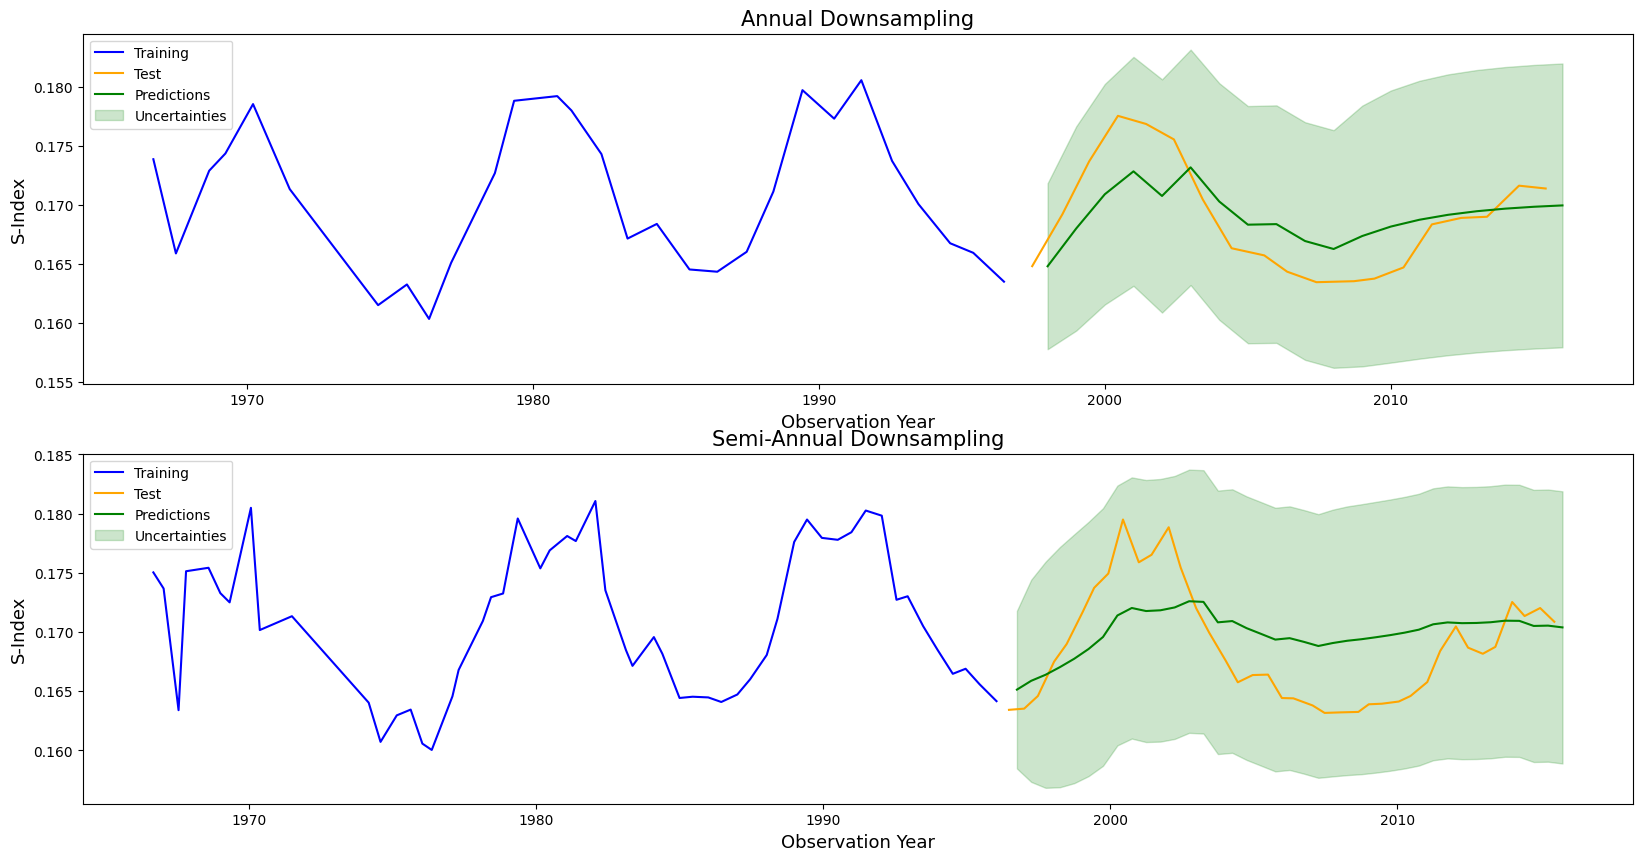

In [47]:
fig, ax = plt.subplots(2, figsize=(20,10))

plot_predictions(
    trainingset= train_df_year,
    validset= valid_df_year,
    results= results_year,
    ax = ax[0]
                 )

plot_predictions(
    trainingset= train_df_6me,
    validset= valid_df_6me,
    results= results_6me,
    ax = ax[1]
                 )

ax[0].legend()
ax[0].set_title("Annual Downsampling", fontsize=15)
ax[1].legend()
ax[1].set_title("Semi-Annual Downsampling", fontsize=15)
# plot_predictions(
#     trainingset= train_df_gapme,
#     validset= valid_df_gapme,
#     results= results_gapme,
#                  )

fig.savefig(r"../../Report/Figures/SolarARIMA.png")

- This is pretty bad across the board. 
- The fact of the matter is that we simply do not have very much data. The training section encompasses less than two full cycles.
- Not enough data to fit an ARIMA comfortably.

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

datasets = {
    "year"  : (valid_df_year,  results_year),
    "6me"   : (valid_df_6me,   results_6me),
    # "gapme" : (valid_df_gapme, results_gapme),
}

print(f"{'Model':<8} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
print("-" * 42)
for name, (valid_df, results) in datasets.items():
    actual = valid_df['sind']
    mae    = mean_absolute_error(actual, results['forecast'])
    rmse   = root_mean_squared_error(actual, results['forecast'])
    mape   = (np.abs((actual - results['forecast']) / actual)).mean() * 100
    print(f"{name:<8} {mae:>10.5f} {rmse:>10.5f} {mape:>9.2f}%")

Model           MAE       RMSE       MAPE
------------------------------------------
year        0.00237    0.00288      1.40%
6me         0.00345    0.00399      2.05%


#### Moving window analysis

In [ ]:
import warnings

def moving_window_arima(data_df, label, m, n_windows=8, train_low=0.3, train_high=0.9):
    """
    Produces one figure with n_windows stacked subplots.
    Test = last 1% (fixed). Train/valid split crawls from train_low to train_high of the working data.
    Pure ARIMA fitted directly to sind at each window – no Fourier term.
    """
    n = len(data_df)
    n_test = max(1, round(0.01 * n))
    working  = data_df.iloc[:n - n_test].copy()
    test_set = data_df.iloc[n - n_test:].copy()
    n_work   = len(working)

    train_fracs = np.linspace(train_low, train_high, n_windows)

    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)
    fig.suptitle(f'Moving Window Analysis – {label}', fontsize=15, y=1.001)

    for idx, train_frac in enumerate(train_fracs):
        ax = axes[idx]
        n_train = max(10, round(train_frac * n_work))
        train   = working.iloc[:n_train]
        valid   = working.iloc[n_train:]

        if len(valid) == 0:
            ax.set_title(f'Window {idx+1}: no validation data')
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = pm.auto_arima(
                    train['sind'],
                    seasonal=True,
                    start_p=2, start_q=2,
                    stepwise=True,
                    information_criterion='aicc',
                    d=0, D=0,
                    maxp=10, maxq=10,
                    suppress_warnings=True, error_action='ignore',
                    m=m,
                )
        except Exception:
            ax.set_title(f'Window {idx+1}/{n_windows}: ARIMA fit failed')
            continue

        n_valid = len(valid)
        try:
            fc, ci = model.predict(n_periods=n_valid, return_conf_int=True)
        except Exception:
            ax.set_title(f'Window {idx+1}/{n_windows}: forecast failed')
            continue

        mae  = np.mean(np.abs(fc - valid['sind'].values))
        mape = np.mean(np.abs((fc - valid['sind'].values) / valid['sind'].values)) * 100

        ax.plot(train['year'], train['sind'],
                color='blue', linewidth=1.5, label='Training')
        ax.plot(valid['year'], valid['sind'],
                color='orange', linewidth=1.5, label='Validation')
        ax.plot(valid['year'], fc,
                color='green', linewidth=2, label='Predictions')
        ax.fill_between(valid['year'], ci[:, 0], ci[:, 1],
                        color='green', alpha=0.2, label='Uncertainties')
        if len(test_set) > 0:
            ax.plot(test_set['year'], test_set['sind'],
                    color='grey', linewidth=1.5, linestyle='--', label='Test (1%)')

        ax.axvline(train['year'].iloc[-1], color='#aaaaaa', linewidth=1, linestyle='--')

        ax.set_ylabel('S-Index', fontsize=13)
        ax.set_title(
            f'Window {idx+1}/{n_windows}  |  train n={n_train}, valid n={n_valid}  |  '
            f'MAE={mae:.5f}   MAPE={mape:.2f}%   order={model.order} seasonal={model.seasonal_order}',
            fontsize=10
        )
        if idx == 0:
            ax.legend(fontsize=13, framealpha=0.9)

    axes[-1].set_xlabel('Observation Year', fontsize=13)
    plt.tight_layout()
    plt.show()


moving_window_arima(data_df_year, 'Annual (YE)',       m=11, n_windows=8)
moving_window_arima(data_df_6me,  'Semi-annual (6ME)', m=22, n_windows=8)


#### Fourier ARIMAX
- The model does not take into account that we have prior knowledge that the solar cycle is vaguely 11 years long 
- Let's try modelling this with a $$y=\textbf{ARIMA} + c + \sum_k (Asin(2k\pi t/T) + B cos(2k\pi t/T))$$

- Unfortunately, we're still dependent on the rather irritating downsampling business.
- We will start by fitting the oscillating term to the full data.
- The cos + sin lets us fit any phase shift and the value of T can be initial guess of 11 years.
- Then we can take the residuals and perform ARIMA on those.
- Let's write a general function that can fit for several values of $k_{max}$

In [49]:
# Define the function to fit
# For the curve fit to work with different orders of k, we must use a generator function to create the fittable func

def make_oscfunc(k):
    def oscfunc(t, T, c, *coeffs):
        # coeffs = [A_0, A_1, ..., A_{k-1}, B_0, B_1, ..., B_{k-1}]
        A = coeffs[:k]
        B = coeffs[k:]
        y = np.ones_like(t) * c
        for i in range(0,k):
            x = 2 * (i + 1) * np.pi * t / T
            y += A[i] * np.sin(x) + B[i] * np.cos(x)
        
        return y 
    return oscfunc

In [50]:
from scipy.optimize import curve_fit

def fit_for_order(k, t, y): 
    '''
    Returns the T and sinusoid coefficients for a Fourier series k
    t and y are the data arrays
    we do not have to downsample so just use the full data arrays
    '''
    fit_func = make_oscfunc(k)

    # Initial guesses
    p0 = [11] + [0.17] + [0.005] * k + [0.005] * k # 11 because time t is measured in years and fracitons thereof

    # params, cov = curve_fit(fit_func, t, y, p0 = p0, maxfev = 10000)

    params, cov = curve_fit(
    fit_func, t, y,
    p0=p0,
    bounds=([8,  -np.inf] + [-np.inf]*2*k,
            [14,  np.inf] + [ np.inf]*2*k),
    max_nfev=10000,
    )


    T_fit     = params[0]
    c_fit      = params[1]
    A_fit     = params[2 : k+2]
    B_fit     = params[k+2 :]

    return T_fit, c_fit, A_fit, B_fit

- Let's fit k = 1, 2, 3 and compare with some kind of goodness of fit test.

In [51]:
T_fit_1, c_fit_1, A_fit_1, B_fit_1 = fit_for_order(1, train_df["year"], train_df['sind'])

In [52]:
T_fit_2, c_fit_2, A_fit_2, B_fit_2 = fit_for_order(2, train_df["year"], train_df['sind'])

In [53]:
T_fit_3, c_fit_3, A_fit_3, B_fit_3 = fit_for_order(3, train_df["year"], train_df['sind'])

In [54]:
for k, (T, c, A, B) in enumerate([(T_fit_1, c_fit_1, A_fit_1, B_fit_1),
                                   (T_fit_2, c_fit_2, A_fit_2, B_fit_2),
                                   (T_fit_3, c_fit_3, A_fit_3, B_fit_3)], start=1):
    print(f"k={k}  T={T:.4f}  c={c:.4f}  A={np.round(A, 4)}  B={np.round(B, 4)}")


k=1  T=10.3659  c=0.1711  A=[0.0033]  B=[0.0068]
k=2  T=10.3752  c=0.1711  A=[-0.0045 -0.0005]  B=[ 0.006  -0.0008]
k=3  T=10.4293  c=0.1711  A=[-0.0044 -0.0006  0.0003]  B=[ 0.0062 -0.0006  0.0009]


In [55]:
oscfunc_1 = make_oscfunc(1)
oscfunc_2 = make_oscfunc(2)
oscfunc_3 = make_oscfunc(3)

- Now perform model comparison using AIC

In [56]:
def AIC(y_true, y_pred, k):
    '''
    Calculates the AIC of the three models for comparison
    Assumes Gaussian likelihood
    '''
    n = len(y_true)
    n_params = 2* k  +2
    resids = y_true - y_pred
    tot_resid = np.sum(resids**2)

    lnL = -n/2 * np.log(2 * np.pi * tot_resid/n) - tot_resid / (2* tot_resid/n)

    aic = 2 * n_params - 2 * lnL

    return aic

In [57]:
AIC_1 = AIC(train_df['sind'], oscfunc_1(train_df['year'], T_fit_1, c_fit_1, *np.concatenate([A_fit_1, B_fit_1])), k = 1)
AIC_2 = AIC(train_df['sind'], oscfunc_2(train_df['year'], T_fit_2, c_fit_2, *np.concatenate([A_fit_2, B_fit_2])), k = 2)
AIC_3 = AIC(train_df['sind'], oscfunc_3(train_df['year'], T_fit_3, c_fit_3, *np.concatenate([A_fit_3, B_fit_3])), k = 3)

In [58]:
def print_aic_table(train_df, fits):
    '''fits: list of (k, T, c, A, B, oscfunc)'''
    print(f"{'k':<6} {'AIC':>10}")
    print("-" * 18)
    for k, T, c, A, B, oscfunc in fits:
        y_pred = oscfunc(train_df['year'], T, c, *np.concatenate([A, B]))
        aic    = AIC(train_df['sind'], y_pred, k=k)
        print(f"{k:<6} {aic:>10.4f}")

fits = [
    (1, T_fit_1, c_fit_1, A_fit_1, B_fit_1, oscfunc_1),
    (2, T_fit_2, c_fit_2, A_fit_2, B_fit_2, oscfunc_2),
    (3, T_fit_3, c_fit_3, A_fit_3, B_fit_3, oscfunc_3),
]

print_aic_table(train_df, fits)

k             AIC
------------------
1      -31615.5616
2      -31716.5842
3      -31810.8801


- Lower AIC is better so let's go with 3 modes.

### Now let's try fitting the ARIMA to the residuals vs the three mode Fourier.

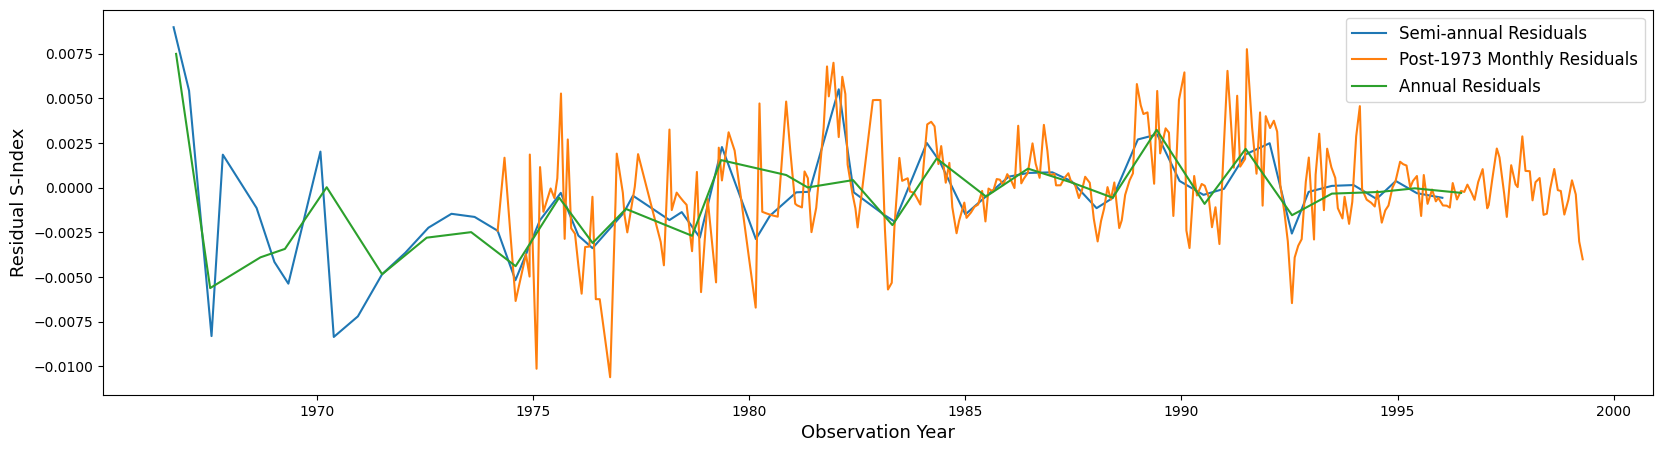

In [60]:
# Create the residual dataset by taking our three downsampled datasets, taking the time out predicting for that time, and then taking the residual
# The k = 3 func is oscfunc_3
# T_fit_3, c_fit_3, A_fit_3, B_fit_3
# The three downsampled datasets are _year, _6me, _gapme

# Add a residual to each of the dataframes
base = oscfunc_3(
    train_df_gapme['year'],
    T_fit_3,
    c_fit_3,
    *np.concatenate([A_fit_3,B_fit_3])
)
resid = train_df_gapme['sind'] - base
train_df_gapme['sind_resid'] = resid

base = oscfunc_3(
    train_df_year['year'],
    T_fit_3,
    c_fit_3,
    *np.concatenate([A_fit_3,B_fit_3])
)
resid = train_df_year['sind'] - base
train_df_year['sind_resid'] = resid

base = oscfunc_3(
    train_df_6me['year'],
    T_fit_3,
    c_fit_3,
    *np.concatenate([A_fit_3,B_fit_3])
)
resid = train_df_6me['sind'] - base
train_df_6me['sind_resid'] = resid

# Plot
fig, ax = plt.subplots(figsize=(20,5))
ax.plot(train_df_6me['year'], train_df_6me['sind_resid'], label="Semi-annual Residuals")
ax.plot(train_df_gapme['year'], train_df_gapme['sind_resid'], label="Post-1973 Monthly Residuals")
ax.plot(train_df_year['year'], train_df_year['sind_resid'], label="Annual Residuals")
ax.set_ylabel("Residual S-Index", fontsize=13)
ax.set_xlabel("Observation Year", fontsize=13)
ax.legend(fontsize=12)
fig.savefig(r"../../Report/Figures/FourierResids.png")

- Let's examine these with a ACF/PACF

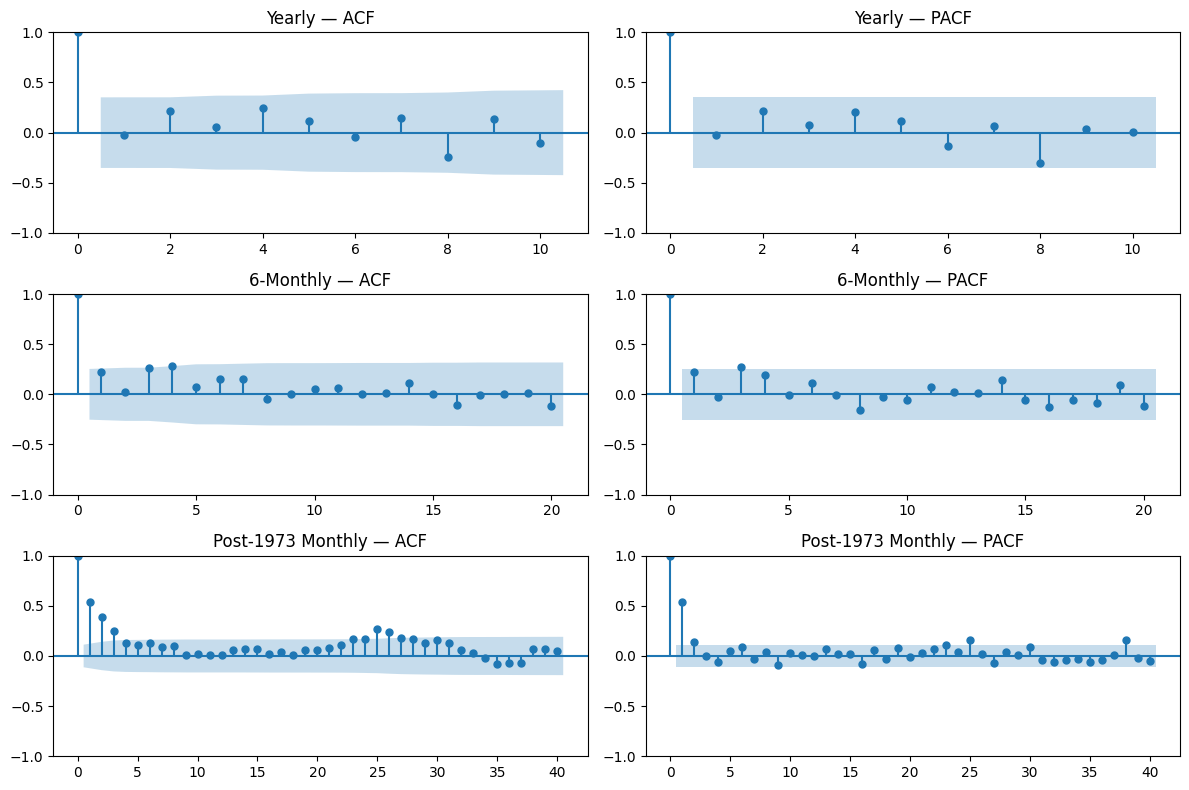

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(12, 8))

plot_acf(train_df_year['sind_resid'],   lags=10, ax=ax[0,0])
plot_pacf(train_df_year['sind_resid'],  lags=10, ax=ax[0,1])
ax[0,0].set_title('Yearly â€” ACF')
ax[0,1].set_title('Yearly â€” PACF')

plot_acf(train_df_6me['sind_resid'],    lags=20, ax=ax[1,0])
plot_pacf(train_df_6me['sind_resid'],   lags=20, ax=ax[1,1])
ax[1,0].set_title('6-Monthly â€” ACF')
ax[1,1].set_title('6-Monthly â€” PACF')

plot_acf(train_df_gapme['sind_resid'],  lags=40, ax=ax[2,0])
plot_pacf(train_df_gapme['sind_resid'], lags=40, ax=ax[2,1])
ax[2,0].set_title('Post-1973 Monthly â€” ACF')
ax[2,1].set_title('Post-1973 Monthly â€” PACF')

plt.tight_layout()
plt.show()

- This looks stationary. 
- The data is dependent on very short-term effects, though.

In [ ]:
model_year_r = pm.auto_arima( # _r is residual
    train_df_year['sind_resid'],
    # seasonal = True, # the cycle is longer than that
    start_q = 2,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    maxp = 10,
    maxq = 10,
    trace = True,
    # m =11,
)

Performing stepwise search to minimize aicc
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AICC=-271.180, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AICC=-277.552, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AICC=-275.122, Time=0.12 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AICC=-274.993, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AICC=-277.329, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.29 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 1.063 seconds


In [ ]:
model_6me_r = pm.auto_arima(
    train_df_6me['sind_resid'],
    # seasonal = True, # the cycle is longer than that
    start_q = 2,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    maxp = 10,
    maxq = 10,
    trace = True,
    # m = 22,
)

Performing stepwise search to minimize aicc
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AICC=-517.392, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AICC=-522.802, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AICC=-524.085, Time=0.17 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AICC=-523.948, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AICC=-521.184, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AICC=-521.788, Time=0.26 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AICC=-521.676, Time=0.34 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AICC=-519.487, Time=0.43 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AICC=-524.482, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AICC=-521.939, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AICC=-516.825, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AICC=-524.204, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AICC=-520.057, Time=0.26 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 2.354 seconds


In [ ]:
model_gapme_r = pm.auto_arima(
    train_df_gapme['sind_resid'],
    # seasonal = True, # the cycle is longer than that
    start_q = 2,
    stepwise = True,
    information_criterion='aicc',
    d = 0,
    maxp = 10,
    maxq = 10,
    trace = True,
    # m =132
)

Performing stepwise search to minimize aicc
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AICC=-2796.416, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AICC=-2696.180, Time=0.17 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AICC=-2796.182, Time=0.26 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AICC=-2761.270, Time=0.26 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AICC=-2697.922, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AICC=-2798.436, Time=0.27 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AICC=-2784.277, Time=0.43 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AICC=-2799.504, Time=0.46 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AICC=-2798.043, Time=0.21 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AICC=-2800.111, Time=0.14 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AICC=-2798.042, Time=0.24 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AICC=-2795.989, Time=0.58 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AICC=-2802.038, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AICC=-2798.082, Time=0.08 sec
 ARI

- Now reconstruct the predictions and plot

In [ ]:
# Predict the forecasts
forecast_gapme_r, conf_gapme_r = model_gapme_r.predict(n_periods=len(valid_df_gapme), return_conf_int=True)
forecast_year_r, conf_year_r = model_year_r.predict(n_periods=len(valid_df_year), return_conf_int=True)
forecast_6me_r, conf_6me_r = model_6me_r.predict(n_periods=len(valid_df_6me), return_conf_int=True)

# Adding the bases

base_gapme = oscfunc_3(
    valid_df_gapme['year'],
    T_fit_3,
    c_fit_3,
    *np.concatenate([A_fit_3,B_fit_3])
)

results_gapme_r = pd.DataFrame({
    'forecast' : forecast_gapme_r.values,
    'lower'    : base_gapme + conf_gapme_r[:, 0],
    'upper'    : base_gapme + conf_gapme_r[:, 1],
}, index=valid_df_gapme.index)

# 

base_year = oscfunc_3(
    valid_df_year['year'],
    T_fit_3,
    c_fit_3,
    *np.concatenate([A_fit_3,B_fit_3])
)

results_year_r = pd.DataFrame({
    'forecast' : forecast_year_r.values,
    'lower'    : base_year + conf_year_r[:, 0],
    'upper'    : base_year + conf_year_r[:, 1],
}, index=valid_df_year.index)

#

base_6me = oscfunc_3(
    valid_df_6me['year'],
    T_fit_3,
    c_fit_3,
    *np.concatenate([A_fit_3,B_fit_3])
)

results_6me_r = pd.DataFrame({
    'forecast' : forecast_6me_r.values,
    'lower'    : base_6me + conf_6me_r[:, 0],
    'upper'    : base_6me + conf_6me_r[:, 1],
}, index=valid_df_6me.index)

In [ ]:
def plot_predictions_osc(trainingset, validset, results, base):
    fig, ax = plt.subplots(figsize=(20, 10))

    ax.plot(trainingset['year'], trainingset['sind'], 
            color='#2c7bb6', linewidth=1.5, label='Training')
    ax.plot(validset['year'], validset['sind'], 
            color='#d7191c', linewidth=1.5, label='Actual')
    
    results_time = results.index.to_series().apply(
        lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25
    )
    
    ax.plot(results_time, base + results['forecast'], 
            color='#1a9641', linewidth=2, label='Predictions')
#     ax.plot(results_time, results['forecast'], 
#             color='#a6d96a', linewidth=1.5, linestyle='--', label='ARIMA term')
    ax.plot(results_time, base, 
            color='#fdae61', linewidth=1.5, linestyle=':', label='Oscillating term')
    
    ax.fill_between(results_time, results['lower'], results['upper'], 
                    color='#1a9641', alpha=0.15, label='Uncertainties')

    ax.set_facecolor('#f9f9f9')
    fig.patch.set_facecolor('white')
    ax.grid(True, color='white', linewidth=1.2)
    ax.spines[['top', 'right']].set_visible(False)

    plt.legend(framealpha=0.9, edgecolor='#cccccc')
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_predictions_osc(trainingset, validset, results, base):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

    results_time = results.index.to_series().apply(
        lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25
    )

    # --- Top plot: full series + predictions ---
    ax1.plot(trainingset['year'], trainingset['sind'],
             color='#2c7bb6', linewidth=1.5, label='Training')
    ax1.plot(validset['year'], validset['sind'],
             color='#d7191c', linewidth=1.5, label='Actual')
    ax1.plot(results_time, base + results['forecast'],
             color='#1a9641', linewidth=2, label='Predictions')
    ax1.plot(results_time, base,
             color='#fdae61', linewidth=1.5, linestyle=':', label='Oscillating term')
    ax1.fill_between(results_time, results['lower'], results['upper'],
                     color='#1a9641', alpha=0.15, label='Uncertainties')
    ax1.set_ylabel('sind')
    ax1.legend(framealpha=0.9, edgecolor='#cccccc')

    # --- Bottom plot: ARIMA term only ---
    ax2.plot(results_time, results['forecast'],
             color='#a6d96a', linewidth=1.5, label='ARIMA term')
    ax2.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
    ax2.set_ylabel('ARIMA residual')
    ax2.set_xlabel('Year')
    ax2.legend(framealpha=0.9, edgecolor='#cccccc')

    arima_max = results['forecast'].abs().max() * 1.2
    ax2.set_ylim(-arima_max, arima_max)

    # --- Shared styling ---
    for ax in (ax1, ax2):
        ax.set_facecolor('#f9f9f9')
        ax.grid(True, color='white', linewidth=1.2)
        ax.spines[['top', 'right']].set_visible(False)

    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()

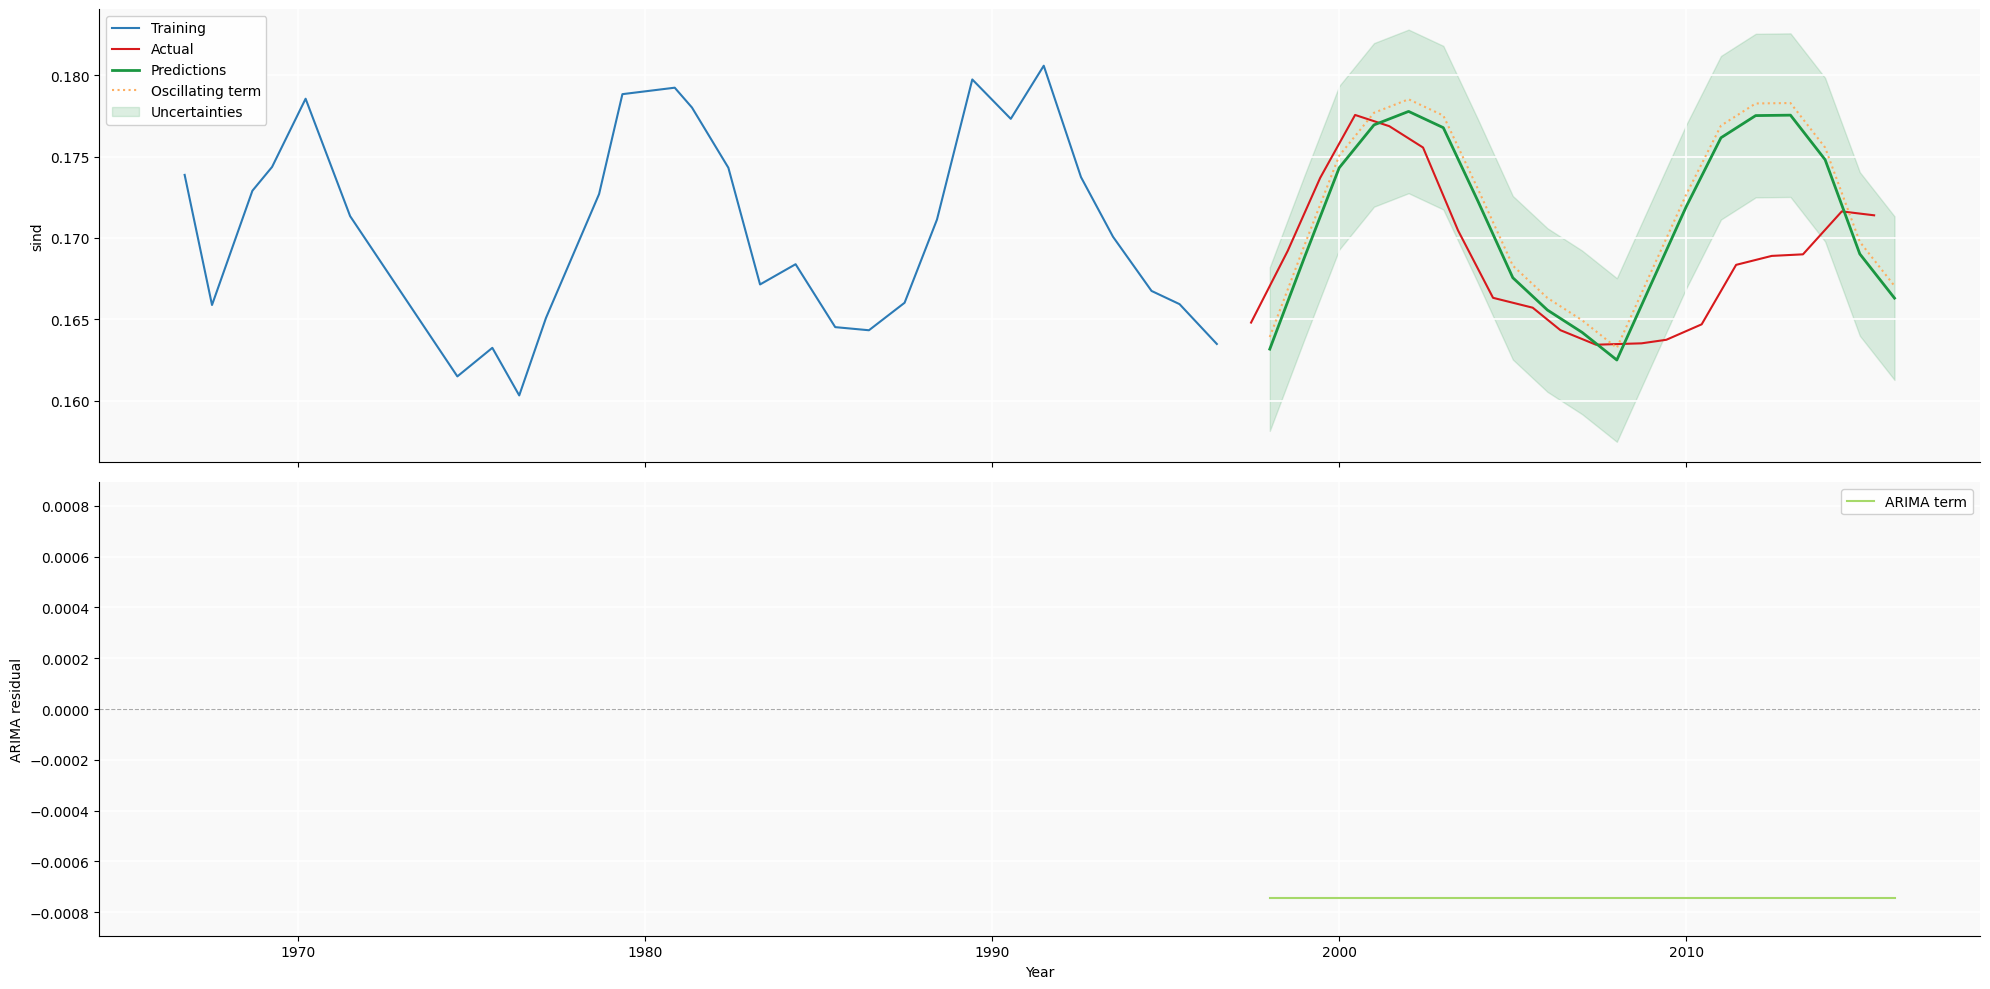

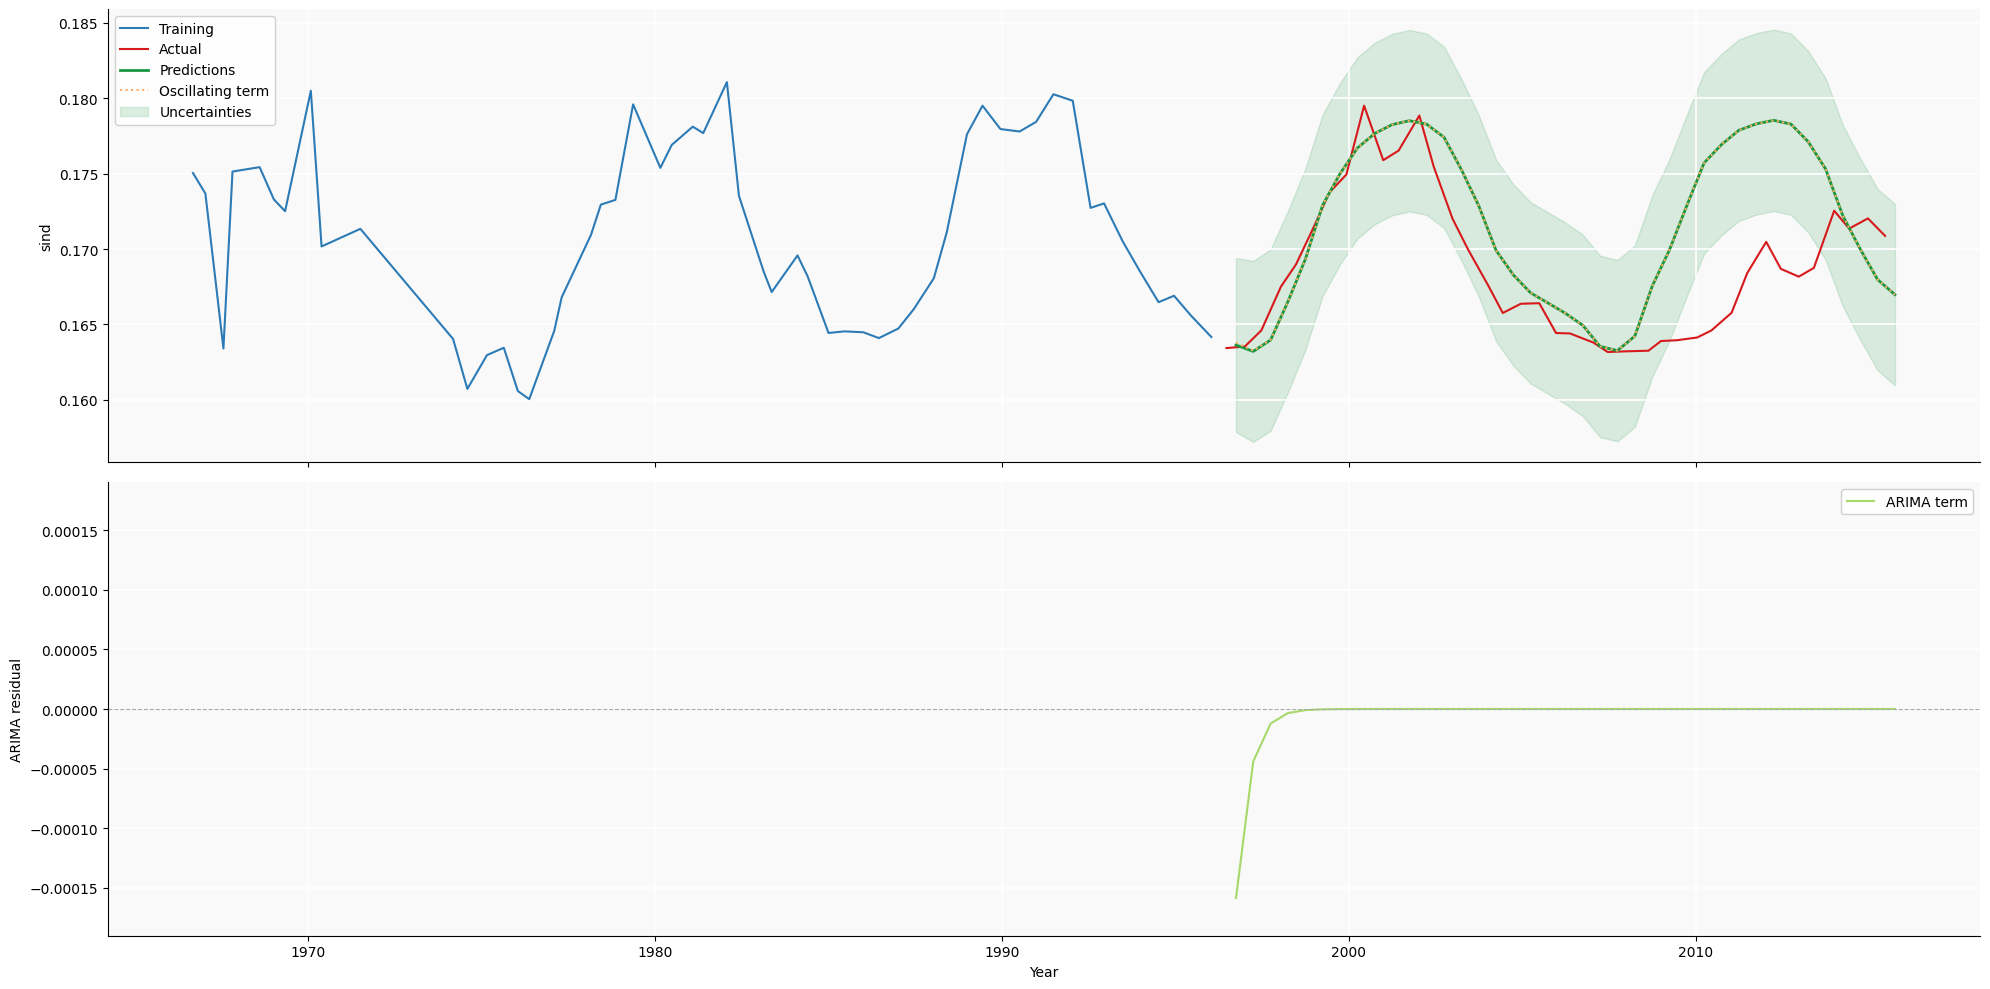

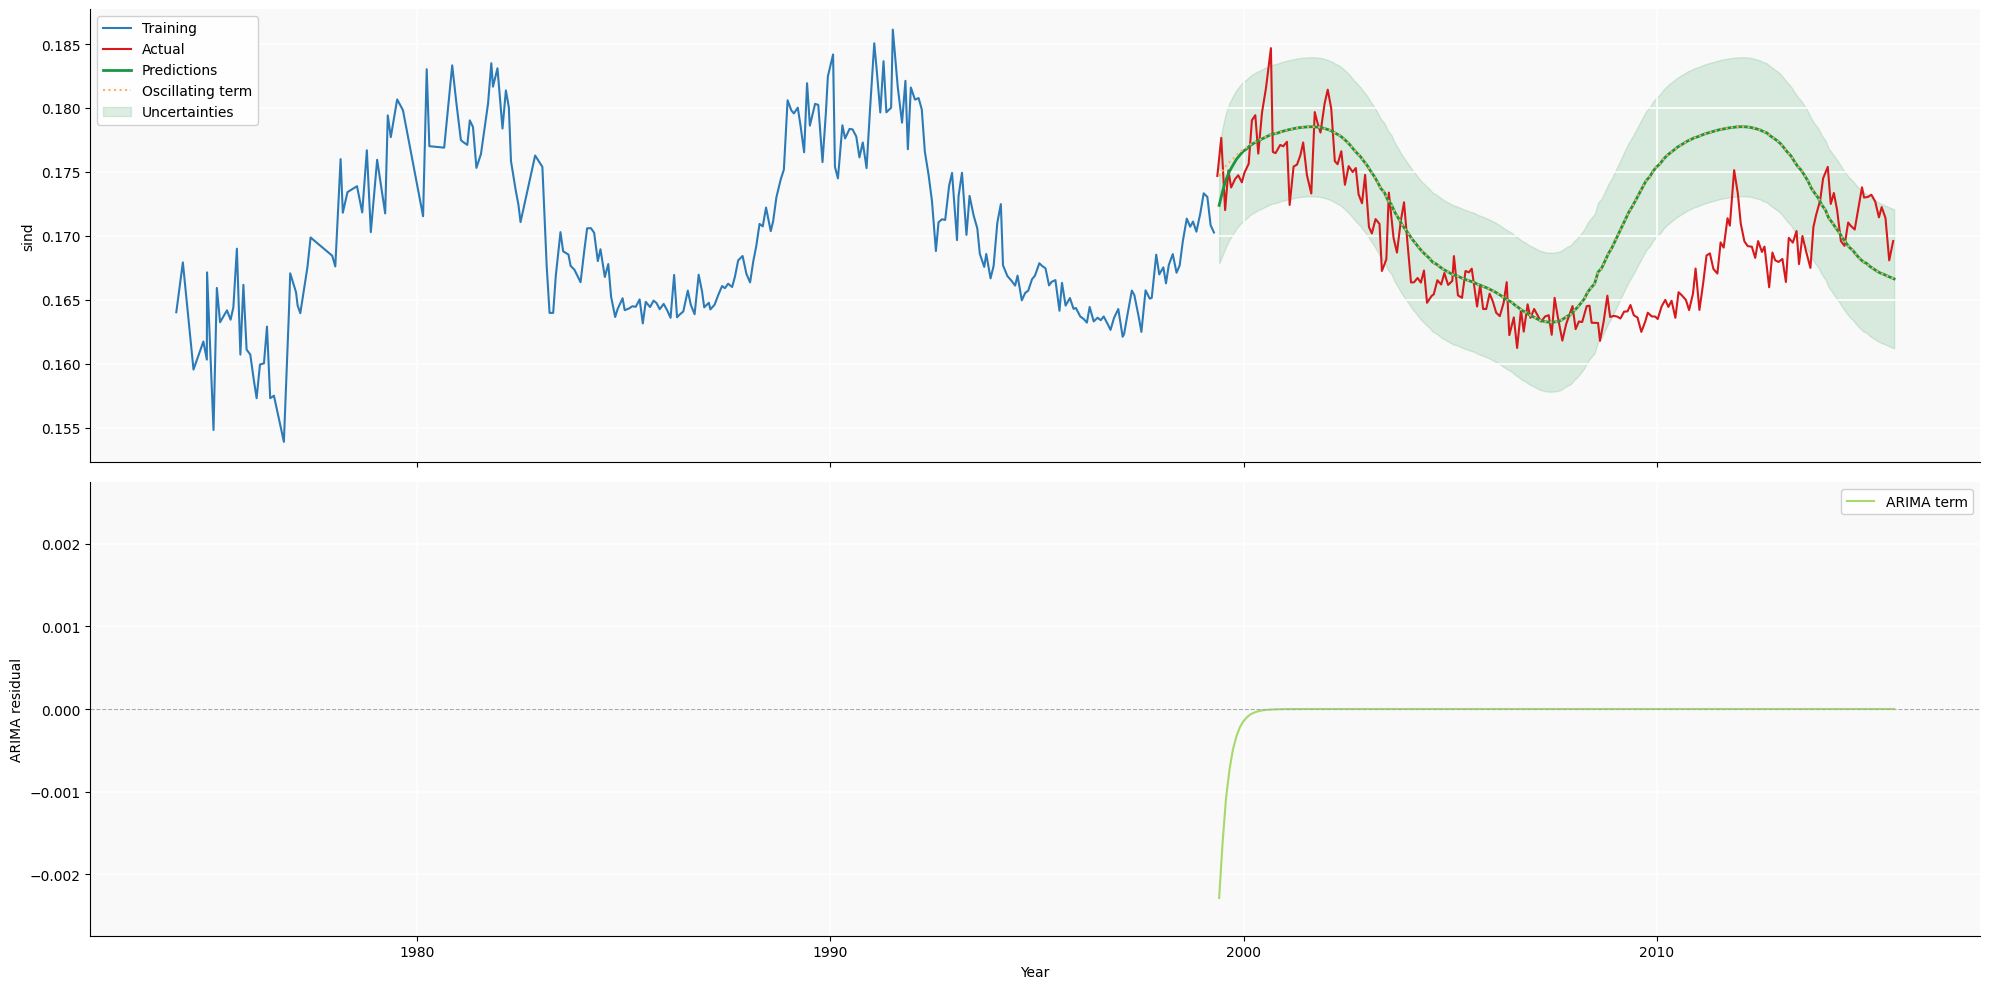

In [ ]:
plot_predictions_osc(
    trainingset= train_df_year,
    validset= valid_df_year,
    results= results_year_r,
    base = base_year
                 )

plot_predictions_osc(
    trainingset= train_df_6me,
    validset= valid_df_6me,
    results= results_6me_r,
    base = base_6me
                 )

plot_predictions_osc(
    trainingset= train_df_gapme,
    validset= valid_df_gapme,
    results= results_gapme_r,
    base =  base_gapme
                 )

- It appears that the ARIMA term is dominated by the Fourier series term here. 
- Perhaps part of the problem is our limited training data. This is due to the forcible downsampling. There are parts of the data with higher density and there is noise added by the interpolation. 
- Let's trying doing a GPR which allows us to predict with respect to all the data that we have: no need to downsample or interpolate.
- We can introduce cyclical behaviour using a periodic kernel.
- We have very few cycles of training data for the ARIMA. ARIMA is frequentist so this is a problem.
- This motivates trying the analysis with Gaussian methods like GPR.

In [ ]:
# Window analysis with subplots
from matplotlib.gridspec import GridSpec

def moving_window_fourier_arima(data_df, label, n_windows=8, train_low=0.3, train_high=0.9):
    n = len(data_df)
    n_test   = max(1, round(0.01 * n))
    working  = data_df.iloc[:n - n_test].copy()
    test_set = data_df.iloc[n - n_test:].copy()
    n_work   = len(working)

    train_fracs = np.linspace(train_low, train_high, n_windows)

    fig = plt.figure(figsize=(20, 7 * n_windows))
    gs  = GridSpec(2 * n_windows, 1, figure=fig,
                   height_ratios=[3, 1] * n_windows, hspace=0.4,
                   top=0.97, bottom=0.02, left=0.07, right=0.98)
    fig.suptitle(f'Moving Window Analysis (Fourier + ARIMA) - {label}', fontsize=15, y=0.99)

    last_ax2 = None

    for idx, train_frac in enumerate(train_fracs):
        ax1 = fig.add_subplot(gs[2 * idx])
        ax2 = fig.add_subplot(gs[2 * idx + 1], sharex=ax1)
        last_ax2 = ax2

        n_train = max(10, round(train_frac * n_work))
        train   = working.iloc[:n_train]
        valid   = working.iloc[n_train:]

        if len(valid) == 0:
            ax1.set_title(f'Window {idx+1}: no validation data')
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                T_f, c_f, A_f, B_f = fit_for_order(3, train['year'].values, train['sind'].values)
        except Exception:
            ax1.set_title(f'Window {idx+1}/{n_windows}: Fourier fit failed')
            continue

        osc    = make_oscfunc(3)
        coeffs = np.concatenate([A_f, B_f])

        base_tr  = osc(train['year'].values, T_f, c_f, *coeffs)
        resid_tr = train['sind'].values - base_tr

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model_r = pm.auto_arima(
                    resid_tr,
                    start_q=2, stepwise=True,
                    information_criterion='aicc',
                    d=0, maxp=5, maxq=5,
                    suppress_warnings=True, error_action='ignore',
                )
        except Exception:
            ax1.set_title(f'Window {idx+1}/{n_windows}: ARIMA fit failed')
            continue

        n_valid = len(valid)
        try:
            fc, ci = model_r.predict(n_periods=n_valid, return_conf_int=True)
        except Exception:
            ax1.set_title(f'Window {idx+1}/{n_windows}: forecast failed')
            continue

        base_valid = osc(valid['year'].values, T_f, c_f, *coeffs)
        pred  = base_valid + fc
        lower = base_valid + ci[:, 0]
        upper = base_valid + ci[:, 1]

        mae  = np.mean(np.abs(pred - valid['sind'].values))
        mape = np.mean(np.abs((pred - valid['sind'].values) / valid['sind'].values)) * 100

        ax1.plot(train['year'], train['sind'],
                 color='blue', linewidth=1.5, label='Training')
        ax1.plot(valid['year'], valid['sind'],
                 color='orange', linewidth=1.5, label='Validation')
        ax1.plot(valid['year'], pred,
                 color='green', linewidth=2, label='Predictions')
        ax1.plot(valid['year'], base_valid,
                 color='purple', linewidth=1.5, linestyle=':', label='Fourier term')
        ax1.fill_between(valid['year'], lower, upper,
                         color='green', alpha=0.2, label='Uncertainties')
        if len(test_set) > 0:
            ax1.plot(test_set['year'], test_set['sind'],
                     color='grey', linewidth=1.5, linestyle='--', label='Test (1%)')
        ax1.axvline(train['year'].iloc[-1], color='#aaaaaa', linewidth=1, linestyle='--')
        ax1.set_ylabel('S-Index', fontsize=13)
        ax1.set_title(
            f'Window {idx+1}/{n_windows}  |  train n={n_train}, valid n={n_valid}  |  '
            f'MAE={mae:.5f}   MAPE={mape:.2f}%   ARIMA order={model_r.order}',
            fontsize=10
        )
        if idx == 0:
            ax1.legend(fontsize=13, framealpha=0.9)
        plt.setp(ax1.get_xticklabels(), visible=False)

        ax2.plot(valid['year'], fc,
                 color='green', linewidth=1.5, label='ARIMA residual term')
        ax2.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
        arima_max = np.abs(fc).max() * 1.2 if np.abs(fc).max() > 0 else 1e-4
        ax2.set_ylim(-arima_max, arima_max)
        ax2.set_ylabel('ARIMA\nresidual', fontsize=9)
        if idx == 0:
            ax2.legend(fontsize=13, framealpha=0.9)
        if idx < n_windows - 1:
            plt.setp(ax2.get_xticklabels(), visible=False)

    if last_ax2 is not None:
        last_ax2.set_xlabel('Observation Year', fontsize=13)

    plt.show()


moving_window_fourier_arima(data_df_year, 'Annual (YE)',       n_windows=8)
moving_window_fourier_arima(data_df_6me,  'Semi-annual (6ME)', n_windows=8)
